<a href="https://colab.research.google.com/github/devonpower21-beep/MediTrace/blob/main/Weather_Prediction_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os


drive.mount('/content/drive')


DATA_DIR = '/content/drive/MyDrive/Weather Prediction 2025'


if os.path.exists(DATA_DIR):
    print(f"Found directory: {DATA_DIR}")
    print(f"\nFiles in directory:")
    for file in os.listdir(DATA_DIR):
        print(f"  - {file}")
else:
    print(f"Directory not found: {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found directory: /content/drive/MyDrive/Weather Prediction 2025

Files in directory:
  - test.csv
  - train.csv
  - sample_submission.csv
  - distribution_analysis.png
  - temperature_timeseries.png
  - correlation_heatmap.png
  - feature_importance.png
  - importance_heatmap_by_day.png
  - forest_ensemble_visualization.png
  - tree_statistics.png
  - predictions_visualization.png


## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')


np.random.seed(42)


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


print(" Libraries imported successfully!")

 Libraries imported successfully!


##Load Data

In [ ]:
print("\n[1/12] Loading data files...")

try:
    train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
    test_df = pd.read_csv(f'{DATA_DIR}/test.csv')
    sample_submission = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')
    print(f" Data loaded successfully!")
    print(f"   - Training data: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
    print(f"   - Test data: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
    print(f"\nFirst 5 rows of training data:")
    display(train_df.head())
except FileNotFoundError as e:
    print(f"❌ Error: {e}")


[1/12] Loading data files...
 Data loaded successfully!
   - Training data: 1935 rows, 6 columns
   - Test data: 154 rows, 6 columns

First 5 rows of training data:


,Date,Maximum Temperature degrees (F),Minimum Temperature degrees (F),Precipitation (inches),Snow (inches),Snow Depth (inches)
0,2020-01-01,36.0,13.0,0.00,0.00,5.00
1,2020-01-02,37.0,31.0,0.00,0.00,5.00
2,2020-01-03,36.0,24.0,T,T,4.00
3,2020-01-04,30.0,24.0,0.00,0.00,4.00
4,2020-01-05,38.0,24.0,0.01,T,4.00


##Data Exploration & Visualization

In [ ]:
print("\n[2/12] Exploring data...")


print("\n Dataset Information:")
print(train_df.info())

print("\n Statistical Summary:")
display(train_df.describe())

print("\n Missing Values:")
print(train_df.isnull().sum())


print("\n Trace ('T') Values Count:")
for col in train_df.columns:
    if train_df[col].dtype == 'object' and col != 'Date':
        t_count = (train_df[col] == 'T').sum()
        if t_count > 0:
            print(f"  {col}: {t_count} trace values")


[2/12] Exploring data...

 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1935 entries, 0 to 1934
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             1935 non-null   object 
 1   Maximum Temperature degrees (F)  1935 non-null   float64
 2   Minimum Temperature degrees (F)  1935 non-null   float64
 3   Precipitation (inches)           1935 non-null   object 
 4   Snow (inches)                    1935 non-null   object 
 5   Snow Depth (inches)              1935 non-null   object 
dtypes: float64(2), object(4)
memory usage: 90.8+ KB
None

 Statistical Summary:


,Maximum Temperature degrees (F),Minimum Temperature degrees (F)
count,1935.000000,1935.000000
mean,56.422739,39.030491
std,23.847696,21.897019
min,-6.000000,-19.000000
25%,37.000000,24.000000
50%,57.000000,39.000000
75%,78.000000,59.000000
max,101.000000,79.000000



 Missing Values:
Date                               0
Maximum Temperature degrees (F)    0
Minimum Temperature degrees (F)    0
Precipitation (inches)             0
Snow (inches)                      0
Snow Depth (inches)                0
dtype: int64

 Trace ('T') Values Count:
  Precipitation (inches): 282 trace values
  Snow (inches): 179 trace values
  Snow Depth (inches): 111 trace values


**Temperature Time Series**

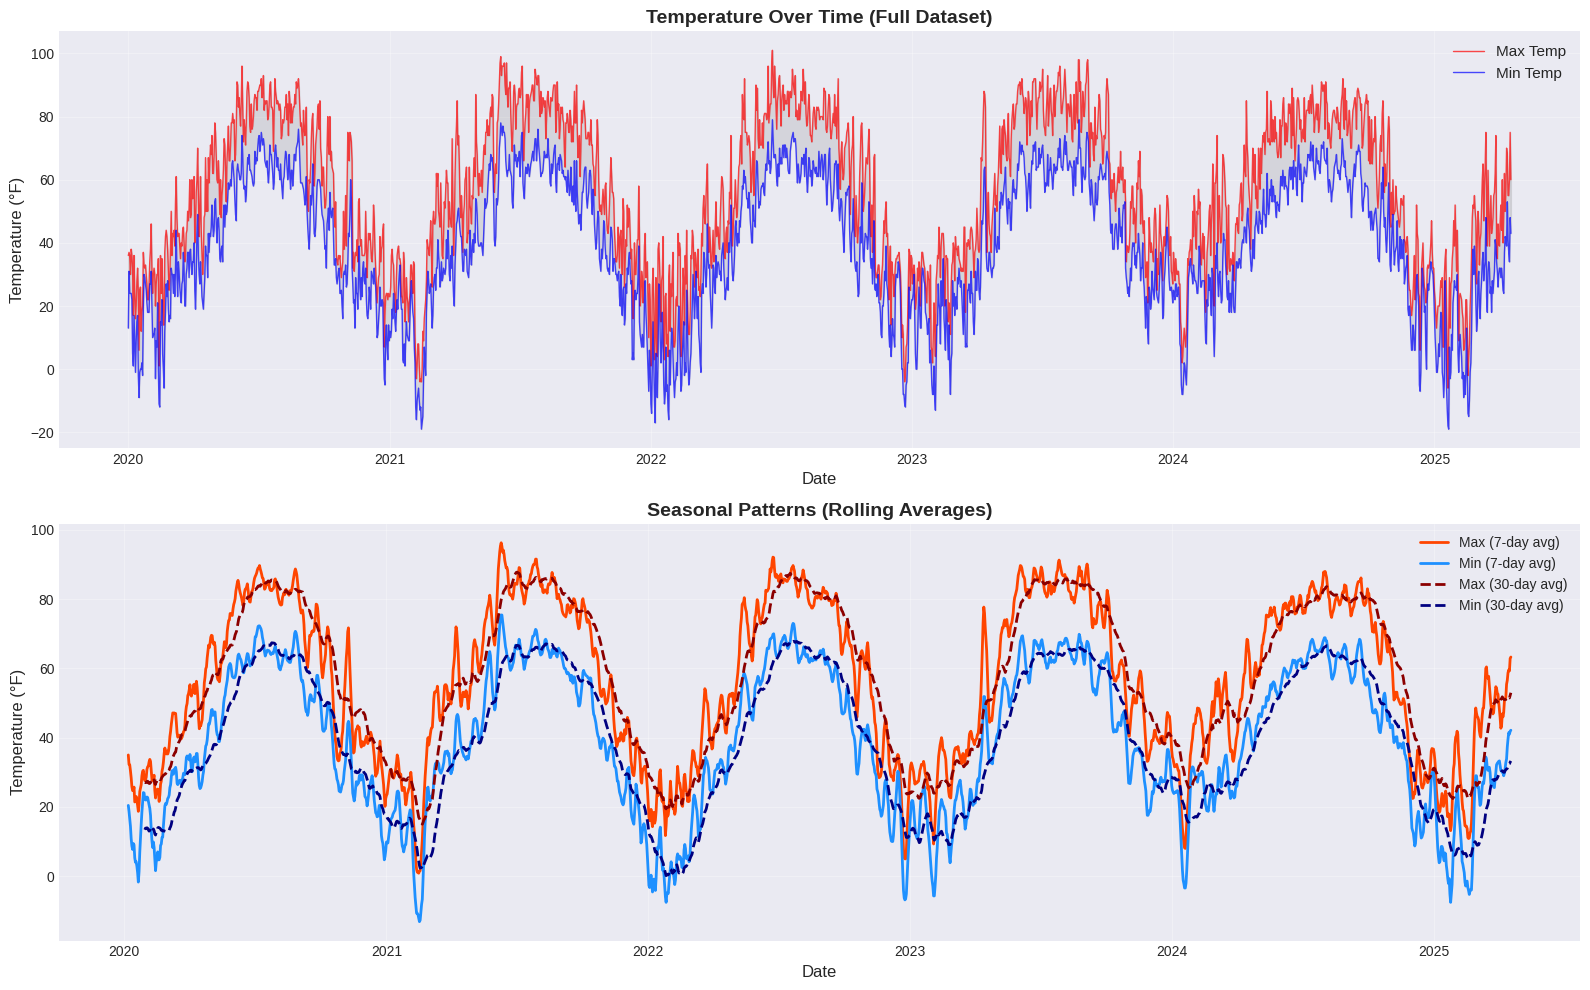

 Visualization saved: temperature_timeseries.png


In [ ]:

train_viz = train_df.copy()
train_viz['Date'] = pd.to_datetime(train_viz['Date'])
train_viz['Maximum Temperature degrees (F)'] = pd.to_numeric(
    train_viz['Maximum Temperature degrees (F)'].replace('T', 0.005), errors='coerce'
)
train_viz['Minimum Temperature degrees (F)'] = pd.to_numeric(
    train_viz['Minimum Temperature degrees (F)'].replace('T', 0.005), errors='coerce'
)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))


axes[0].plot(train_viz['Date'], train_viz['Maximum Temperature degrees (F)'],
             alpha=0.7, label='Max Temp', linewidth=1, color='red')
axes[0].plot(train_viz['Date'], train_viz['Minimum Temperature degrees (F)'],
             alpha=0.7, label='Min Temp', linewidth=1, color='blue')
axes[0].fill_between(train_viz['Date'],
                      train_viz['Minimum Temperature degrees (F)'],
                      train_viz['Maximum Temperature degrees (F)'],
                      alpha=0.2, color='gray')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Temperature (°F)', fontsize=12)
axes[0].set_title('Temperature Over Time (Full Dataset)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)


train_viz['Max_7day'] = train_viz['Maximum Temperature degrees (F)'].rolling(window=7).mean()
train_viz['Min_7day'] = train_viz['Minimum Temperature degrees (F)'].rolling(window=7).mean()
train_viz['Max_30day'] = train_viz['Maximum Temperature degrees (F)'].rolling(window=30).mean()
train_viz['Min_30day'] = train_viz['Minimum Temperature degrees (F)'].rolling(window=30).mean()

axes[1].plot(train_viz['Date'], train_viz['Max_7day'],
             label='Max (7-day avg)', linewidth=2, color='orangered')
axes[1].plot(train_viz['Date'], train_viz['Min_7day'],
             label='Min (7-day avg)', linewidth=2, color='dodgerblue')
axes[1].plot(train_viz['Date'], train_viz['Max_30day'],
             label='Max (30-day avg)', linewidth=2, color='darkred', linestyle='--')
axes[1].plot(train_viz['Date'], train_viz['Min_30day'],
             label='Min (30-day avg)', linewidth=2, color='navy', linestyle='--')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Temperature (°F)', fontsize=12)
axes[1].set_title('Seasonal Patterns (Rolling Averages)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10, loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/temperature_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved: temperature_timeseries.png")

## **Distribution Analysis**

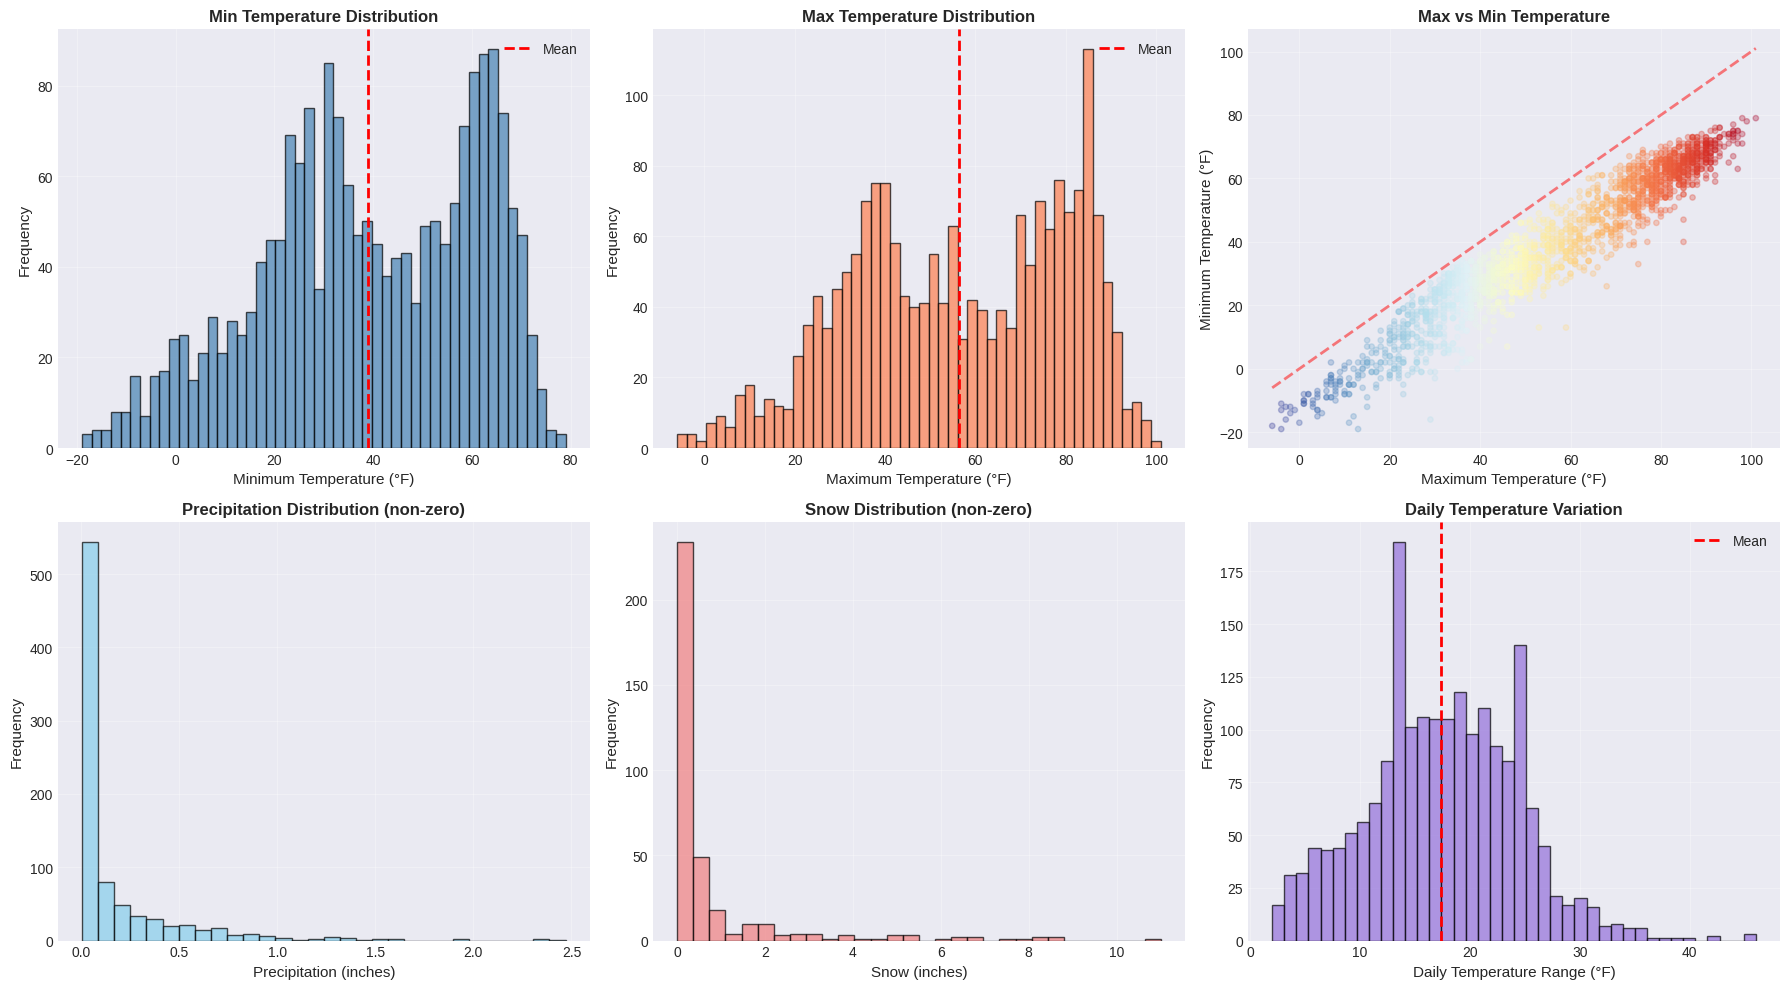

Visualization saved: distribution_analysis.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))


axes[0, 0].hist(train_viz['Minimum Temperature degrees (F)'].dropna(),
                bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(train_viz['Minimum Temperature degrees (F)'].mean(),
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Minimum Temperature (°F)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Min Temperature Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(train_viz['Maximum Temperature degrees (F)'].dropna(),
                bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[0, 1].axvline(train_viz['Maximum Temperature degrees (F)'].mean(),
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].set_xlabel('Maximum Temperature (°F)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Max Temperature Distribution', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)


axes[0, 2].scatter(train_viz['Maximum Temperature degrees (F)'],
                   train_viz['Minimum Temperature degrees (F)'],
                   alpha=0.3, s=15, c=train_viz['Maximum Temperature degrees (F)'],
                   cmap='RdYlBu_r')
axes[0, 2].plot([train_viz['Maximum Temperature degrees (F)'].min(),
                 train_viz['Maximum Temperature degrees (F)'].max()],
                [train_viz['Maximum Temperature degrees (F)'].min(),
                 train_viz['Maximum Temperature degrees (F)'].max()],
                'r--', linewidth=2, alpha=0.5)
axes[0, 2].set_xlabel('Maximum Temperature (°F)', fontsize=11)
axes[0, 2].set_ylabel('Minimum Temperature (°F)', fontsize=11)
axes[0, 2].set_title('Max vs Min Temperature', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)


train_viz['Precipitation (inches)'] = pd.to_numeric(
    train_viz['Precipitation (inches)'].replace('T', 0.005), errors='coerce'
)
precip_nonzero = train_viz[train_viz['Precipitation (inches)'] > 0]['Precipitation (inches)']
axes[1, 0].hist(precip_nonzero, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_xlabel('Precipitation (inches)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Precipitation Distribution (non-zero)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)


train_viz['Snow (inches)'] = pd.to_numeric(
    train_viz['Snow (inches)'].replace('T', 0.005), errors='coerce'
)
snow_nonzero = train_viz[train_viz['Snow (inches)'] > 0]['Snow (inches)']
axes[1, 1].hist(snow_nonzero, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].set_xlabel('Snow (inches)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Snow Distribution (non-zero)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)


train_viz['Temp_Range'] = train_viz['Maximum Temperature degrees (F)'] - train_viz['Minimum Temperature degrees (F)']
axes[1, 2].hist(train_viz['Temp_Range'].dropna(),
                bins=40, alpha=0.7, color='mediumpurple', edgecolor='black')
axes[1, 2].axvline(train_viz['Temp_Range'].mean(),
                   color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 2].set_xlabel('Daily Temperature Range (°F)', fontsize=11)
axes[1, 2].set_ylabel('Frequency', fontsize=11)
axes[1, 2].set_title('Daily Temperature Variation', fontsize=12, fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: distribution_analysis.png")

# **Correlation Heatmap**

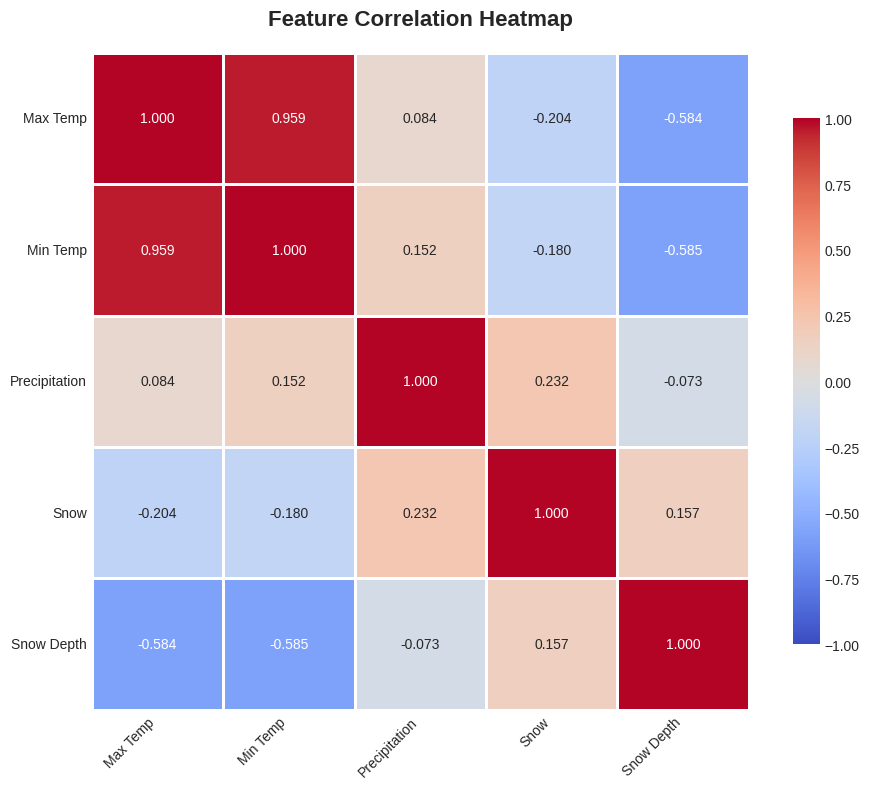

Visualization saved: correlation_heatmap.png

 Key Correlations:
  Max Temp ↔ Min Temp: 0.959
  Snow ↔ Min Temp: -0.180
  Snow ↔ Max Temp: -0.204


In [ ]:

corr_data = train_df.copy()
corr_data['Date'] = pd.to_datetime(corr_data['Date'])

numeric_cols = [
    'Maximum Temperature degrees (F)',
    'Minimum Temperature degrees (F)',
    'Precipitation (inches)',
    'Snow (inches)',
    'Snow Depth (inches)'
]

for col in numeric_cols:
    corr_data[col] = pd.to_numeric(corr_data[col].replace('T', 0.005), errors='coerce')


corr_data_renamed = corr_data[numeric_cols].rename(columns={
    'Maximum Temperature degrees (F)': 'Max Temp',
    'Minimum Temperature degrees (F)': 'Min Temp',
    'Precipitation (inches)': 'Precipitation',
    'Snow (inches)': 'Snow',
    'Snow Depth (inches)': 'Snow Depth'
})


correlation_matrix = corr_data_renamed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: correlation_heatmap.png")
print("\n Key Correlations:")
print(f"  Max Temp ↔ Min Temp: {correlation_matrix.loc['Max Temp', 'Min Temp']:.3f}")
print(f"  Snow ↔ Min Temp: {correlation_matrix.loc['Snow', 'Min Temp']:.3f}")
print(f"  Snow ↔ Max Temp: {correlation_matrix.loc['Snow', 'Max Temp']:.3f}")

# **Data Preprocessing**

In [ ]:
print("\n[3/12] Preprocessing data...")

def preprocess_data(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])

    numeric_cols = [
        'Maximum Temperature degrees (F)',
        'Minimum Temperature degrees (F)',
        'Precipitation (inches)',
        'Snow (inches)',
        'Snow Depth (inches)'
    ]

    for col in numeric_cols:
        df[col] = df[col].replace('T', 0.005)
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

train_clean = preprocess_data(train_df)
test_clean = preprocess_data(test_df)

print(" Data preprocessing complete!")
print(f"   - Replaced 'T' (trace) values with 0.005")
print(f"   - Converted all numeric columns to float")


[3/12] Preprocessing data...
 Data preprocessing complete!
   - Replaced 'T' (trace) values with 0.005
   - Converted all numeric columns to float


# **Create Training Sequences**

In [ ]:
print("\n[4/12] Creating training sequences...")

def create_sequences(df, sequence_length=14):
    feature_cols = [
        'Maximum Temperature degrees (F)',
        'Minimum Temperature degrees (F)',
        'Precipitation (inches)',
        'Snow (inches)',
        'Snow Depth (inches)'
    ]

    X_list = []
    y_list = []

    for i in range(0, len(df) - sequence_length):
        sequence = df.iloc[i:i+sequence_length][feature_cols].values
        X_list.append(sequence.flatten())
        target = df.iloc[i+sequence_length]['Minimum Temperature degrees (F)']
        y_list.append(target)

    X = np.array(X_list)
    y = np.array(y_list)

    return X, y

X_train_full, y_train_full = create_sequences(train_clean, sequence_length=14)

print(f" Training sequences created!")
print(f"   - Total samples: {len(X_train_full)}")
print(f"   - Features per sample: {X_train_full.shape[1]} (14 days × 5 variables)")


[4/12] Creating training sequences...
 Training sequences created!
   - Total samples: 1921
   - Features per sample: 70 (14 days × 5 variables)


# **Split Data for Validation**

In [ ]:
print("\n[5/12] Splitting data for validation...")

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42
)

print(f" Data split complete!")
print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Validation set: {X_val.shape[0]} samples")
print(f"\n Target Statistics (Training):")
print(f"   - Mean: {y_train.mean():.2f}°F")
print(f"   - Std: {y_train.std():.2f}°F")
print(f"   - Min: {y_train.min():.2f}°F")
print(f"   - Max: {y_train.max():.2f}°F")


[5/12] Splitting data for validation...
 Data split complete!
   - Training set: 1536 samples
   - Validation set: 385 samples

 Target Statistics (Training):
   - Mean: 38.89°F
   - Std: 21.78°F
   - Min: -19.00°F
   - Max: 79.00°F


# **Train Random Forest Model**

In [ ]:
print("\n[6/12] Training Random Forest model...")
print("\n Model Parameters:")
print("   - Number of trees: 200")
print("   - Max depth: 20")
print("   - Min samples split: 5")
print("   - Min samples leaf: 2")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\n Training in progress...")
rf_model.fit(X_train, y_train)

print("\n Model training complete!")


[6/12] Training Random Forest model...

 Model Parameters:
   - Number of trees: 200
   - Max depth: 20
   - Min samples split: 5
   - Min samples leaf: 2

 Training in progress...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s



 Model training complete!


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.7s finished


# **Evaluate Model Performance**

In [ ]:
print("\n[7/12] Evaluating model performance...")

y_pred_train = rf_model.predict(X_train)
y_pred_val = rf_model.predict(X_val)

train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

val_mae = mean_absolute_error(y_val, y_pred_val)
val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
val_r2 = r2_score(y_val, y_pred_val)

print("\n" + "="*70)
print("   MODEL PERFORMANCE METRICS")
print("="*70)
print("\n Training Set:")
print(f"   MAE (Mean Absolute Error):  {train_mae:.3f}°F")
print(f"   RMSE (Root Mean Squared):   {train_rmse:.3f}°F")
print(f"   R² Score:                   {train_r2:.4f}")
print("\n Validation Set:")
print(f"   MAE (Mean Absolute Error):  {val_mae:.3f}°F")
print(f"   RMSE (Root Mean Squared):   {val_rmse:.3f}°F")
print(f"   R² Score:                   {val_r2:.4f}")
print("\n" + "="*70)
print(f" Average prediction error: ±{val_mae:.2f}°F")
print("="*70)


[7/12] Evaluating model performance...

   MODEL PERFORMANCE METRICS

 Training Set:
   MAE (Mean Absolute Error):  2.396°F
   RMSE (Root Mean Squared):   3.146°F
   R² Score:                   0.9791

 Validation Set:
   MAE (Mean Absolute Error):  4.724°F
   RMSE (Root Mean Squared):   6.169°F
   R² Score:                   0.9223

 Average prediction error: ±4.72°F


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


# **Model Performance Plots**

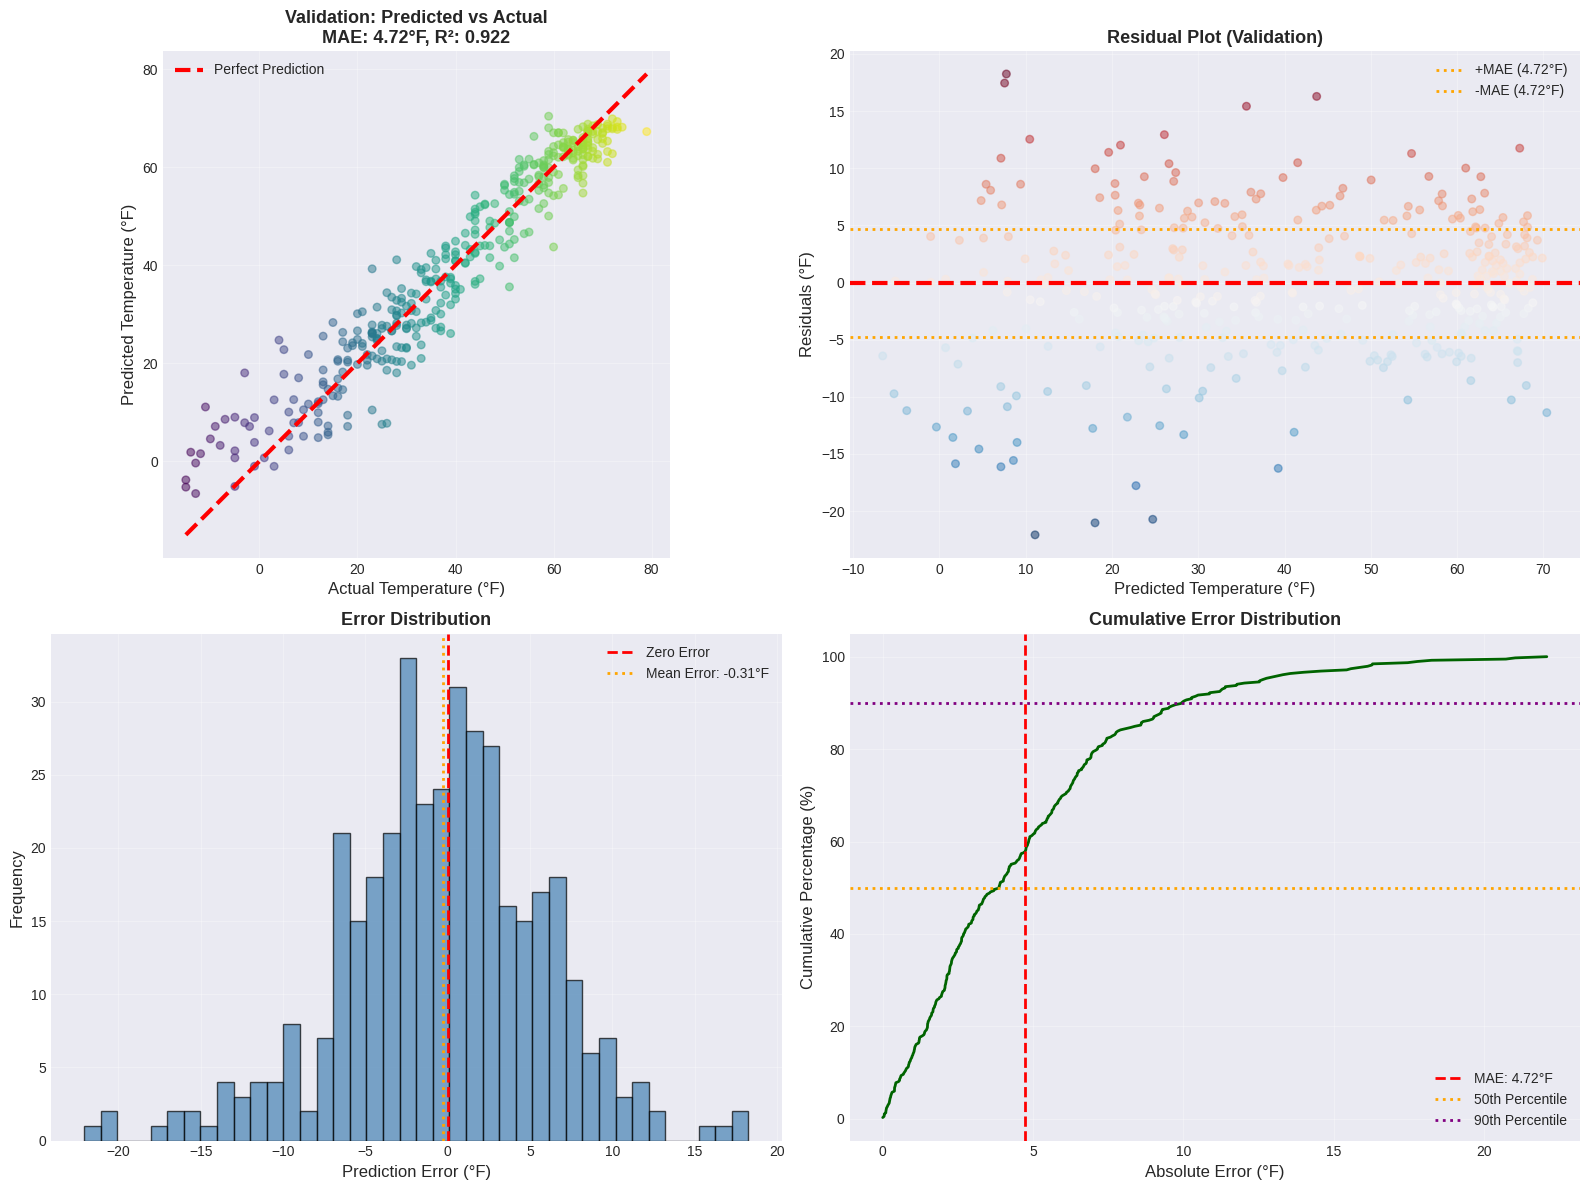

Visualization saved: model_performance.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))


axes[0, 0].scatter(y_val, y_pred_val, alpha=0.5, s=30, c=y_val, cmap='viridis')
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
                'r--', lw=3, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Temperature (°F)', fontsize=12)
axes[0, 0].set_ylabel('Predicted Temperature (°F)', fontsize=12)
axes[0, 0].set_title(f'Validation: Predicted vs Actual\nMAE: {val_mae:.2f}°F, R²: {val_r2:.3f}',
                     fontsize=13, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_aspect('equal', adjustable='box')


residuals = y_val - y_pred_val
axes[0, 1].scatter(y_pred_val, residuals, alpha=0.5, s=30, c=residuals, cmap='RdBu_r')
axes[0, 1].axhline(y=0, color='red', linestyle='--', lw=3)
axes[0, 1].axhline(y=val_mae, color='orange', linestyle=':', lw=2, label=f'+MAE ({val_mae:.2f}°F)')
axes[0, 1].axhline(y=-val_mae, color='orange', linestyle=':', lw=2, label=f'-MAE ({val_mae:.2f}°F)')
axes[0, 1].set_xlabel('Predicted Temperature (°F)', fontsize=12)
axes[0, 1].set_ylabel('Residuals (°F)', fontsize=12)
axes[0, 1].set_title('Residual Plot (Validation)', fontsize=13, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(residuals, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[1, 0].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[1, 0].axvline(residuals.mean(), color='orange', linestyle=':', lw=2,
                   label=f'Mean Error: {residuals.mean():.2f}°F')
axes[1, 0].set_xlabel('Prediction Error (°F)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Error Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)


sorted_abs_errors = np.sort(np.abs(residuals))
cumulative = np.arange(1, len(sorted_abs_errors) + 1) / len(sorted_abs_errors) * 100
axes[1, 1].plot(sorted_abs_errors, cumulative, linewidth=2, color='darkgreen')
axes[1, 1].axvline(val_mae, color='red', linestyle='--', lw=2, label=f'MAE: {val_mae:.2f}°F')
axes[1, 1].axhline(50, color='orange', linestyle=':', lw=2, label='50th Percentile')
axes[1, 1].axhline(90, color='purple', linestyle=':', lw=2, label='90th Percentile')
axes[1, 1].set_xlabel('Absolute Error (°F)', fontsize=12)
axes[1, 1].set_ylabel('Cumulative Percentage (%)', fontsize=12)
axes[1, 1].set_title('Cumulative Error Distribution', fontsize=13, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: model_performance.png")

# **Feature Importance**

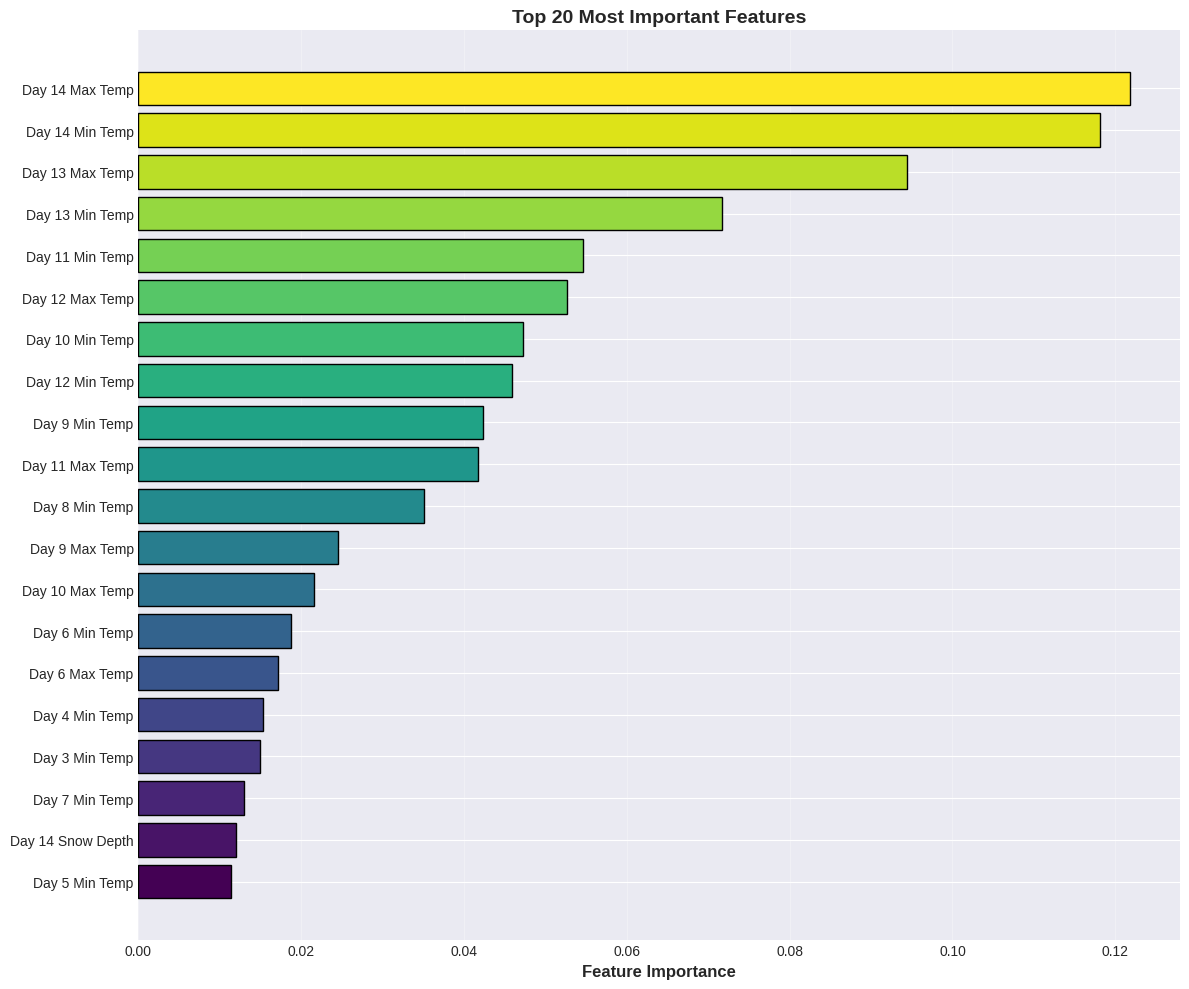

 Visualization saved: feature_importance.png

 Top 10 Most Important Features:
   1. Day 14 Max Temp           - Importance: 0.1219
   2. Day 14 Min Temp           - Importance: 0.1181
   3. Day 13 Max Temp           - Importance: 0.0944
   4. Day 13 Min Temp           - Importance: 0.0717
   5. Day 11 Min Temp           - Importance: 0.0546
   6. Day 12 Max Temp           - Importance: 0.0526
   7. Day 10 Min Temp           - Importance: 0.0472
   8. Day 12 Min Temp           - Importance: 0.0458
   9. Day 9 Min Temp            - Importance: 0.0424
  10. Day 11 Max Temp           - Importance: 0.0418


In [ ]:
feature_importance = rf_model.feature_importances_


feature_names = []
var_names = ['Max Temp', 'Min Temp', 'Precip', 'Snow', 'Snow Depth']
for day in range(1, 15):
    for var in var_names:
        feature_names.append(f'Day {day} {var}')


top_n = 20
indices = np.argsort(feature_importance)[-top_n:]

plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0, 1, top_n))
plt.barh(range(top_n), feature_importance[indices], color=colors, edgecolor='black')
plt.yticks(range(top_n), [feature_names[i] for i in indices], fontsize=10)
plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved: feature_importance.png")
print("\n Top 10 Most Important Features:")
for i, idx in enumerate(indices[-10:][::-1], 1):
    print(f"  {i:2d}. {feature_names[idx]:25s} - Importance: {feature_importance[idx]:.4f}")

# **Feature Importance Heatmap by Day**

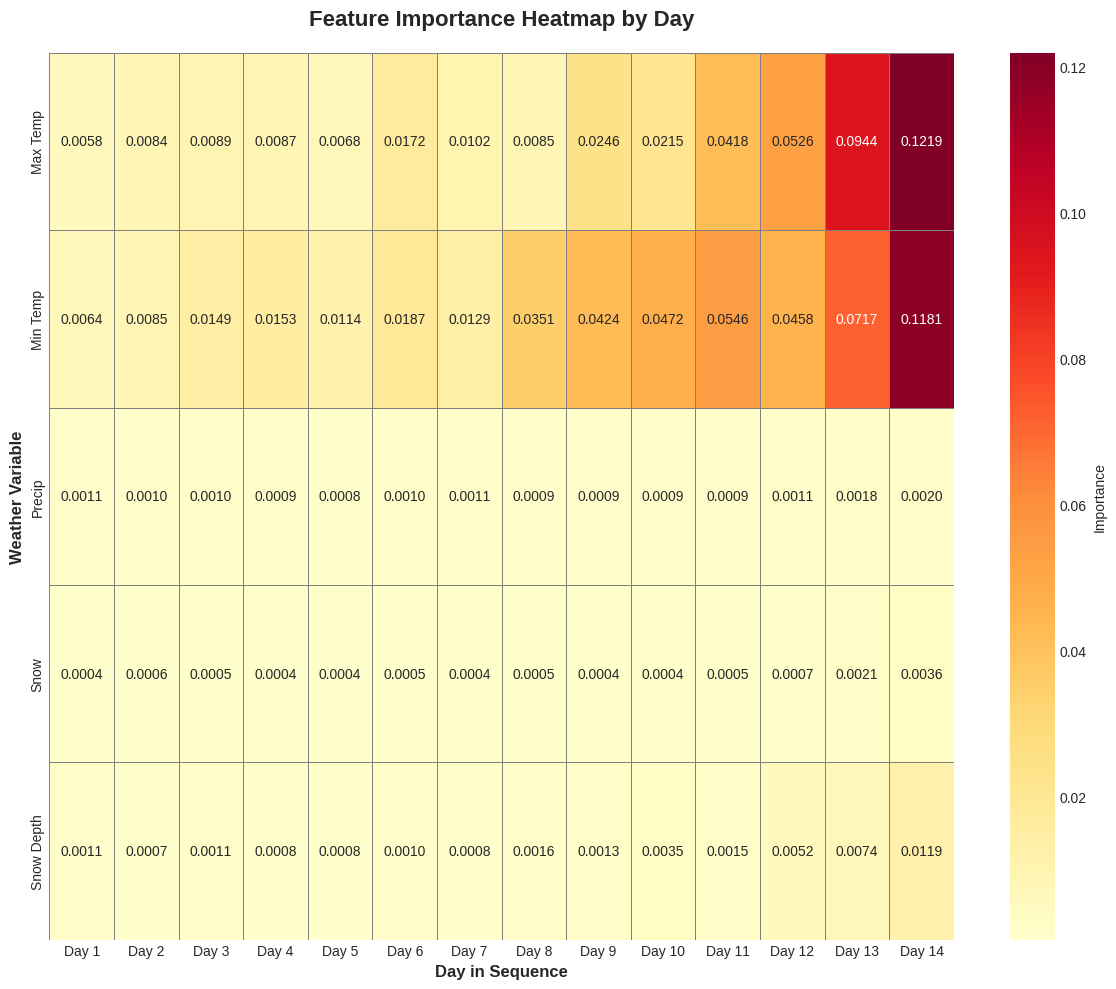

Visualization saved: importance_heatmap_by_day.png

 Insight: Days 13-14 (most recent) typically have highest importance!


In [ ]:

importance_matrix = feature_importance.reshape(14, 5)

plt.figure(figsize=(12, 10))
sns.heatmap(importance_matrix.T, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[f'Day {i+1}' for i in range(14)],
            yticklabels=var_names,
            cbar_kws={'label': 'Importance'},
            linewidths=0.5, linecolor='gray')
plt.title('Feature Importance Heatmap by Day', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Day in Sequence', fontsize=12, fontweight='bold')
plt.ylabel('Weather Variable', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/importance_heatmap_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: importance_heatmap_by_day.png")
print("\n Insight: Days 13-14 (most recent) typically have highest importance!")

# **Retrain on Full Dataset**

In [ ]:
print("\n[8/12] Retraining on full dataset for final predictions...")

rf_model_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model_final.fit(X_train_full, y_train_full)

print("\n Final model training complete!")


[8/12] Retraining on full dataset for final predictions...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.2s



 Final model training complete!


[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.9s finished


# **Save Model as PKL File**

In [ ]:
print("\n[9/12] Saving model...")


model_path = f'{DATA_DIR}/random_forest_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(rf_model_final, f)

print(f" Model saved successfully!")
print(f"   - File: random_forest_model.pkl")
print(f"   - Location: {DATA_DIR}")


import os
file_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"   - Size: {file_size:.2f} MB")


metadata = {
    'model_type': 'RandomForestRegressor',
    'n_estimators': 200,
    'max_depth': 20,
    'val_mae': val_mae,
    'val_rmse': val_rmse,
    'val_r2': val_r2,
    'train_samples': len(X_train_full),
    'features': 70,
    'random_state': 42
}

metadata_path = f'{DATA_DIR}/model_metadata.pkl'
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)

print(f"   - Metadata saved: model_metadata.pkl")


[9/12] Saving model...
 Model saved successfully!
   - File: random_forest_model.pkl
   - Location: /content/drive/MyDrive/Weather Prediction 2025
   - Size: 11.94 MB
   - Metadata saved: model_metadata.pkl


# **Test Model Loading**

In [ ]:

print("\n Testing model loading...")

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)


test_prediction = loaded_model.predict(X_val[:5])
print(f" Model loaded and tested successfully!")
print(f"   Sample predictions: {test_prediction[:3]}")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s



 Testing model loading...
 Model loaded and tested successfully!
   Sample predictions: [41.86756548 62.70990927 58.0594605 ]


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


# **Prepare Test Data & Make Predictions**

In [ ]:
print("\n[10/12] Preparing test data...")

def create_test_sequences(df, sequence_length=14):
    feature_cols = [
        'Maximum Temperature degrees (F)',
        'Minimum Temperature degrees (F)',
        'Precipitation (inches)',
        'Snow (inches)',
        'Snow Depth (inches)'
    ]

    X_test_list = []
    n_periods = len(df) // sequence_length

    for period in range(n_periods):
        start_idx = period * sequence_length
        end_idx = start_idx + sequence_length
        sequence = df.iloc[start_idx:end_idx][feature_cols].values
        X_test_list.append(sequence.flatten())

    X_test = np.array(X_test_list)
    return X_test, n_periods

X_test, n_periods = create_test_sequences(test_clean, sequence_length=14)

print(f"Test sequences created!")
print(f"   - Number of prediction periods: {n_periods}")


[10/12] Preparing test data...
Test sequences created!
   - Number of prediction periods: 11


In [ ]:
print("\n[11/12] Generating predictions...")

predictions = rf_model_final.predict(X_test)

print(f" Predictions generated!")
print(f"\n Predicted Minimum Temperatures:")
print("="*70)
for i, pred in enumerate(predictions):
    print(f"  Period {i:2d} (ID {i}): {pred:.2f}°F")
print("="*70)
print(f"\n Summary Statistics:")
print(f"   Mean prediction: {predictions.mean():.2f}°F")
print(f"   Min prediction:  {predictions.min():.2f}°F")
print(f"   Max prediction:  {predictions.max():.2f}°F")
print(f"   Std deviation:   {predictions.std():.2f}°F")


[11/12] Generating predictions...
 Predictions generated!

 Predicted Minimum Temperatures:
  Period  0 (ID 0): 53.56°F
  Period  1 (ID 1): 40.93°F
  Period  2 (ID 2): 56.09°F
  Period  3 (ID 3): 64.74°F
  Period  4 (ID 4): 66.86°F
  Period  5 (ID 5): 62.50°F
  Period  6 (ID 6): 64.07°F
  Period  7 (ID 7): 67.99°F
  Period  8 (ID 8): 52.56°F
  Period  9 (ID 9): 64.81°F
  Period 10 (ID 10): 64.76°F

 Summary Statistics:
   Mean prediction: 59.90°F
   Min prediction:  40.93°F
   Max prediction:  67.99°F
   Std deviation:   7.85°F


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.1s finished


# **Prediction Visualization**

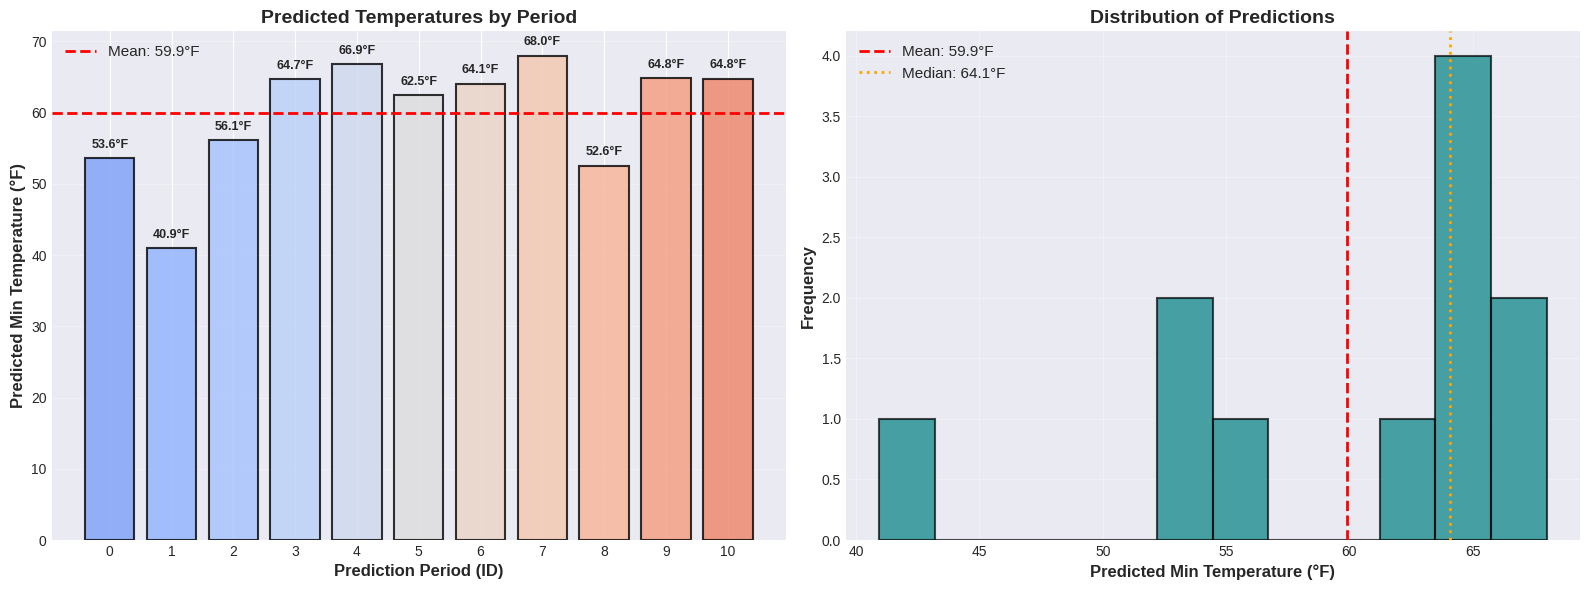

 Visualization saved: predictions_visualization.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


colors = plt.cm.coolwarm(np.linspace(0.2, 0.8, len(predictions)))
axes[0].bar(range(len(predictions)), predictions, color=colors,
            alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].axhline(predictions.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {predictions.mean():.1f}°F')
axes[0].set_xlabel('Prediction Period (ID)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Min Temperature (°F)', fontsize=12, fontweight='bold')
axes[0].set_title('Predicted Temperatures by Period', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(predictions)))
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')


for i, (x, y) in enumerate(zip(range(len(predictions)), predictions)):
    axes[0].text(x, y + 1, f'{y:.1f}°F', ha='center', va='bottom',
                fontsize=9, fontweight='bold')


axes[1].hist(predictions, bins=12, color='teal', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].axvline(predictions.mean(), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {predictions.mean():.1f}°F')
axes[1].axvline(np.median(predictions), color='orange', linestyle=':',
                linewidth=2, label=f'Median: {np.median(predictions):.1f}°F')
axes[1].set_xlabel('Predicted Min Temperature (°F)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Predictions', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/predictions_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved: predictions_visualization.png")


# **Create Submission File**

In [ ]:
print("\n[12/12] Creating submission file...")

submission = pd.DataFrame({
    'ID': range(len(predictions)),
    'Minimum Temperature degrees (F)': predictions
})


submission_path = f'{DATA_DIR}/submission.csv'
submission.to_csv(submission_path, index=False)

print("="*70)
print("\nPreview:")
display(submission)
print(f"\n File saved to: {submission_path}")


[12/12] Creating submission file...

Preview:


,ID,Minimum Temperature degrees (F)
0,0,53.559565
1,1,40.930917
2,2,56.089079
3,3,64.736286
4,4,66.855203
5,5,62.497918
6,6,64.071620
7,7,67.994503
8,8,52.563479
9,9,64.810863



 File saved to: /content/drive/MyDrive/Weather Prediction 2025/submission.csv


# **Summary of Generated Files**

In [ ]:
print(f"\nAll files saved to: {DATA_DIR}\n")

files_created = [
    ('submission.csv', 'Competition submission file'),
    ('random_forest_model.pkl', 'Trained Random Forest model'),
    ('model_metadata.pkl', 'Model configuration and metrics'),
    ('temperature_timeseries.png', 'Temperature over time visualization'),
    ('distribution_analysis.png', 'Data distribution analysis'),
    ('correlation_heatmap.png', 'Feature correlation heatmap'),
    ('model_performance.png', 'Model performance metrics'),
    ('feature_importance.png', 'Feature importance ranking'),
    ('importance_heatmap_by_day.png', 'Feature importance by day heatmap'),
    ('predictions_visualization.png', 'Final predictions visualization')
]

for filename, description in files_created:
    print(f" {filename:35s} - {description}")

print("\n Model Performance Summary:")
print(f"   Validation MAE:  {val_mae:.3f}°F")
print(f"   Validation RMSE: {val_rmse:.3f}°F")
print(f"   Validation R²:   {val_r2:.4f}")


All files saved to: /content/drive/MyDrive/Weather Prediction 2025

 submission.csv                      - Competition submission file
 random_forest_model.pkl             - Trained Random Forest model
 model_metadata.pkl                  - Model configuration and metrics
 temperature_timeseries.png          - Temperature over time visualization
 distribution_analysis.png           - Data distribution analysis
 correlation_heatmap.png             - Feature correlation heatmap
 model_performance.png               - Model performance metrics
 feature_importance.png              - Feature importance ranking
 importance_heatmap_by_day.png       - Feature importance by day heatmap
 predictions_visualization.png       - Final predictions visualization

 Model Performance Summary:
   Validation MAE:  4.724°F
   Validation RMSE: 6.169°F
   Validation R²:   0.9223


In [ ]:

print("\n Loading your saved model\n")


with open(f'{DATA_DIR}/random_forest_model.pkl', 'rb') as f:
    loaded_rf_model = pickle.load(f)


with open(f'{DATA_DIR}/model_metadata.pkl', 'rb') as f:
    model_info = pickle.load(f)

print("Model loaded successfully!\n")
print("Model Information:")
for key, value in model_info.items():
    print(f"  {key}: {value}")

print("\n 'loaded_rf_model.predict(X)' to make predictions!")


 Loading your saved model

Model loaded successfully!

Model Information:
  model_type: RandomForestRegressor
  n_estimators: 200
  max_depth: 20
  val_mae: 4.723691357182727
  val_rmse: 6.169099610268826
  val_r2: 0.9222525121603155
  train_samples: 1921
  features: 70
  random_state: 42

 'loaded_rf_model.predict(X)' to make predictions!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("\n" + "="*80)
print(" RANDOM FOREST MODEL ARCHITECTURE")
print("="*80)


n_trees = len(rf_model_final.estimators_)
print(f"\n Model Configuration:")
print(f"   Number of Decision Trees: {n_trees}")
print(f"   Max Depth per Tree: {rf_model_final.max_depth}")
print(f"   Min Samples Split: {rf_model_final.min_samples_split}")
print(f"   Min Samples Leaf: {rf_model_final.min_samples_leaf}")
print(f"   Max Features per Split: {rf_model_final.max_features}")
print(f"   Random State: {rf_model_final.random_state}")


print(f"\n Individual Tree Statistics:")
tree_depths = [tree.tree_.max_depth for tree in rf_model_final.estimators_]
tree_leaves = [tree.tree_.n_leaves for tree in rf_model_final.estimators_]
tree_nodes = [tree.tree_.node_count for tree in rf_model_final.estimators_]

print(f"   Average Tree Depth: {np.mean(tree_depths):.2f}")
print(f"   Depth Range: {min(tree_depths)} - {max(tree_depths)}")
print(f"   Average Number of Leaves: {np.mean(tree_leaves):.2f}")
print(f"   Average Number of Nodes: {np.mean(tree_nodes):.2f}")


total_nodes = sum(tree_nodes)
total_leaves = sum(tree_leaves)
print(f"\n Total Model Complexity:")
print(f"   Total Nodes Across All Trees: {total_nodes:,}")
print(f"   Total Leaves Across All Trees: {total_leaves:,}")
print(f"   Average Nodes per Tree: {total_nodes/n_trees:.0f}")

print("\n" + "="*80)


 RANDOM FOREST MODEL ARCHITECTURE

 Model Configuration:
   Number of Decision Trees: 200
   Max Depth per Tree: 20
   Min Samples Split: 5
   Min Samples Leaf: 2
   Max Features per Split: sqrt
   Random State: 42

 Individual Tree Statistics:
   Average Tree Depth: 19.04
   Depth Range: 16 - 20
   Average Number of Leaves: 433.30
   Average Number of Nodes: 865.59

 Total Model Complexity:
   Total Nodes Across All Trees: 173,118
   Total Leaves Across All Trees: 86,659
   Average Nodes per Tree: 866



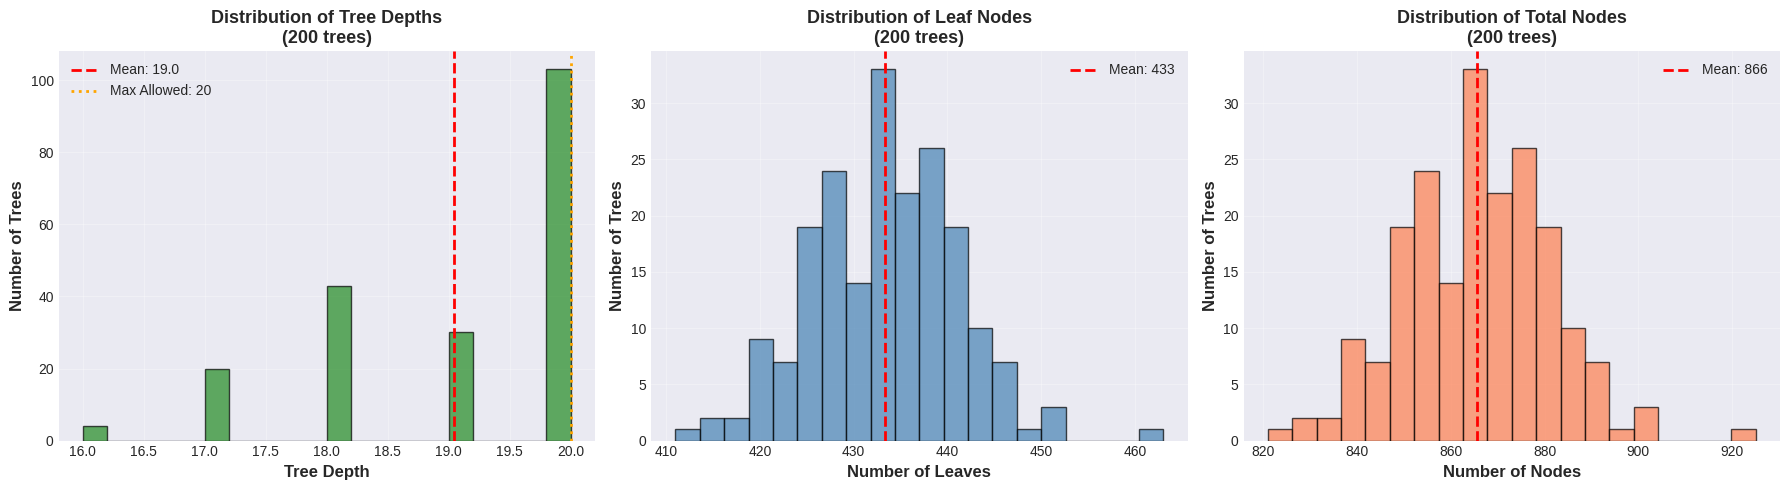

 Visualization saved: tree_statistics.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].hist(tree_depths, bins=20, color='forestgreen', alpha=0.7, edgecolor='black')
axes[0].axvline(np.mean(tree_depths), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(tree_depths):.1f}')
axes[0].axvline(rf_model_final.max_depth, color='orange', linestyle=':', linewidth=2,
                label=f'Max Allowed: {rf_model_final.max_depth}')
axes[0].set_xlabel('Tree Depth', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Trees', fontsize=12, fontweight='bold')
axes[0].set_title(f'Distribution of Tree Depths\n({n_trees} trees)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)


axes[1].hist(tree_leaves, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[1].axvline(np.mean(tree_leaves), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(tree_leaves):.0f}')
axes[1].set_xlabel('Number of Leaves', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Trees', fontsize=12, fontweight='bold')
axes[1].set_title(f'Distribution of Leaf Nodes\n({n_trees} trees)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)


axes[2].hist(tree_nodes, bins=20, color='coral', alpha=0.7, edgecolor='black')
axes[2].axvline(np.mean(tree_nodes), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(tree_nodes):.0f}')
axes[2].set_xlabel('Number of Nodes', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Number of Trees', fontsize=12, fontweight='bold')
axes[2].set_title(f'Distribution of Total Nodes\n({n_trees} trees)',
                  fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/tree_statistics.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualization saved: tree_statistics.png")

In [ ]:
print("\n" + "="*80)
print("TREE ANALYSIS (First 5 Trees)")
print("="*80)

for i in range(min(5, n_trees)):
    tree = rf_model_final.estimators_[i].tree_
    print(f"\n Tree #{i+1}:")
    print(f"   Depth: {tree.max_depth}")
    print(f"   Leaves: {tree.n_leaves}")
    print(f"   Nodes: {tree.node_count}")
    print(f"   Features Used: {len(np.unique(tree.feature[tree.feature >= 0]))}")

print("\n" + "="*80)



TREE ANALYSIS (First 5 Trees)

 Tree #1:
   Depth: 20
   Leaves: 427
   Nodes: 853
   Features Used: 66

 Tree #2:
   Depth: 17
   Leaves: 429
   Nodes: 857
   Features Used: 66

 Tree #3:
   Depth: 20
   Leaves: 434
   Nodes: 867
   Features Used: 67

 Tree #4:
   Depth: 18
   Leaves: 423
   Nodes: 845
   Features Used: 61

 Tree #5:
   Depth: 20
   Leaves: 427
   Nodes: 853
   Features Used: 66



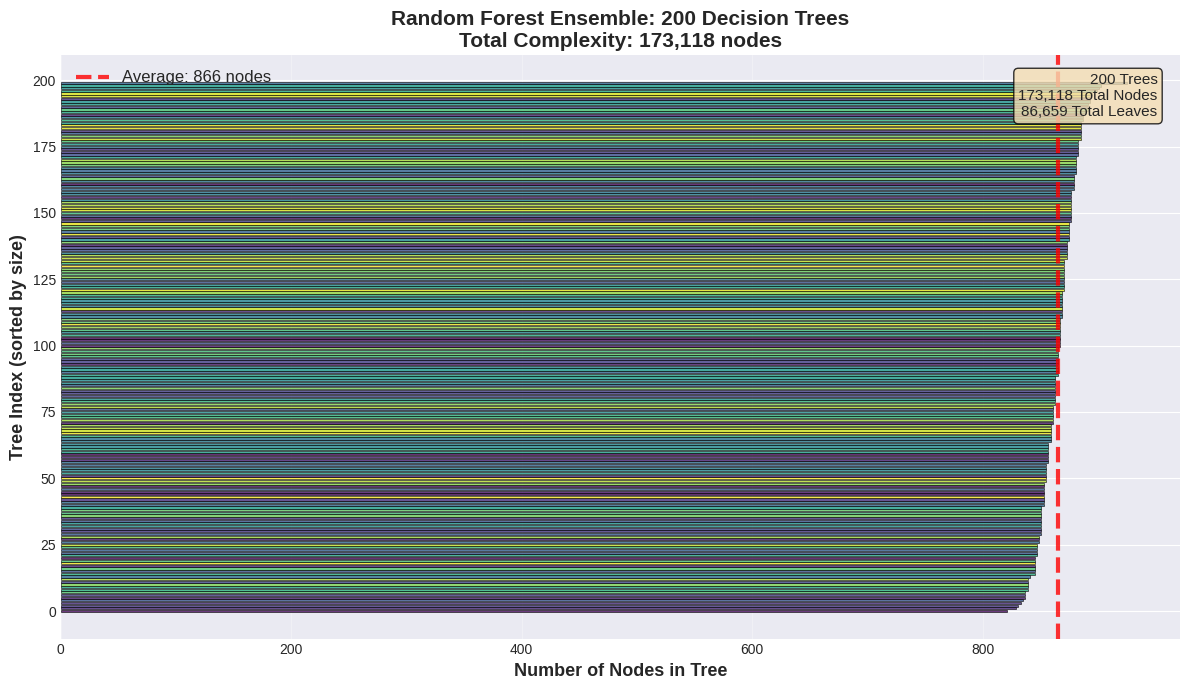

Visualization saved: forest_ensemble_visualization.png


In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

tree_sizes = np.array(tree_nodes)
tree_colors = plt.cm.viridis(np.linspace(0, 1, n_trees))


sorted_indices = np.argsort(tree_sizes)

bars = ax.barh(range(n_trees), tree_sizes[sorted_indices],
               color=tree_colors[sorted_indices], alpha=0.8, edgecolor='black', linewidth=0.5)

ax.axvline(np.mean(tree_nodes), color='red', linestyle='--', linewidth=3,
           label=f'Average: {np.mean(tree_nodes):.0f} nodes', alpha=0.8)

ax.set_xlabel('Number of Nodes in Tree', fontsize=13, fontweight='bold')
ax.set_ylabel('Tree Index (sorted by size)', fontsize=13, fontweight='bold')
ax.set_title(f'Random Forest Ensemble: {n_trees} Decision Trees\nTotal Complexity: {total_nodes:,} nodes',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='x')


ax.text(0.98, 0.97, f'{n_trees} Trees\n{total_nodes:,} Total Nodes\n{total_leaves:,} Total Leaves',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(f'{DATA_DIR}/forest_ensemble_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved: forest_ensemble_visualization.png")

In [ ]:
print("\n" + "="*80)
print("MODEL COMPLEXITY SUMMARY")
print("="*80)
print(f"\n Forest Composition:")
print(f"   • {n_trees} independent decision trees")
print(f"   • Each tree votes on the final prediction")
print(f"   • Final prediction = average of all {n_trees} tree predictions")

print(f"\n Computational Complexity:")
print(f"   • Training samples used: {len(X_train_full):,}")
print(f"   • Features per sample: {X_train_full.shape[1]}")
print(f"   • Total decision nodes: {total_nodes:,}")
print(f"   • Average decisions per prediction: ~{np.mean(tree_depths):.1f}")

print(f"\n Ensemble Advantage:")
print(f"   • {n_trees} diverse perspectives reduce overfitting")
print(f"   • Bootstrap sampling creates tree diversity")
print(f"   • Random feature selection at each split")
print(f"   • Robust to outliers and noise")

print("\n" + "="*80)
print(f"MODEL USES {n_trees} DECISION TREES!")
print("="*80)


MODEL COMPLEXITY SUMMARY

 Forest Composition:
   • 200 independent decision trees
   • Each tree votes on the final prediction
   • Final prediction = average of all 200 tree predictions

 Computational Complexity:
   • Training samples used: 1,921
   • Features per sample: 70
   • Total decision nodes: 173,118
   • Average decisions per prediction: ~19.0

 Ensemble Advantage:
   • 200 diverse perspectives reduce overfitting
   • Bootstrap sampling creates tree diversity
   • Random feature selection at each split
   • Robust to outliers and noise

MODEL USES 200 DECISION TREES!
